In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [31]:
df = pd.read_csv('adult.csv')

In [32]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [34]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [35]:
df.replace('?',None,inplace=True)

In [36]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [37]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,None,103497,Some-college,10,Never-married,None,Own-child,White,Female,0,0,30,United-States,<=50K


In [38]:
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)
df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)

In [39]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

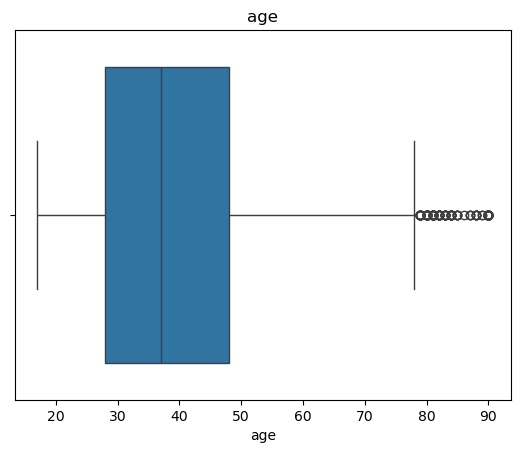

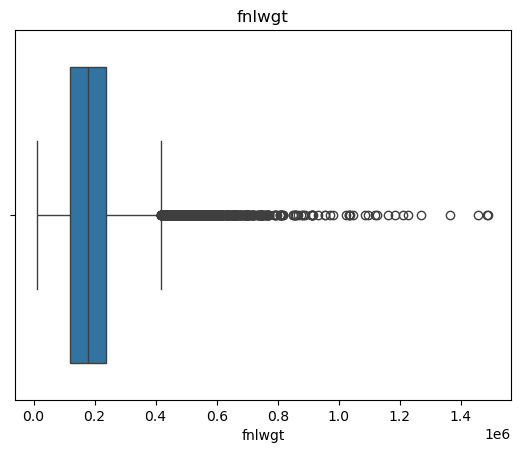

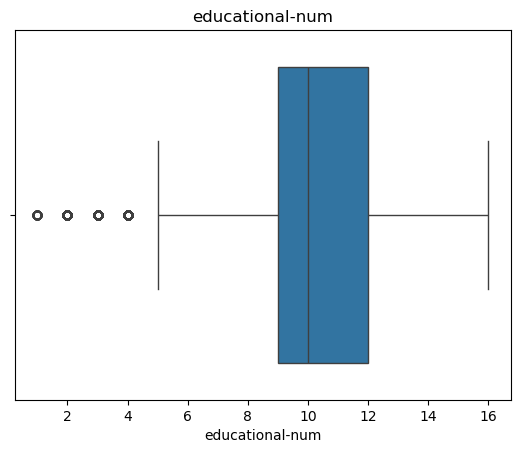

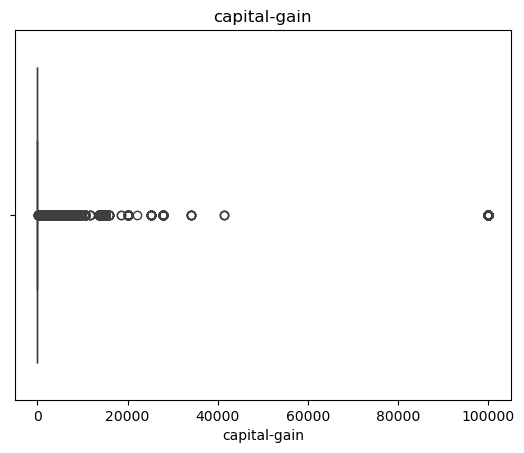

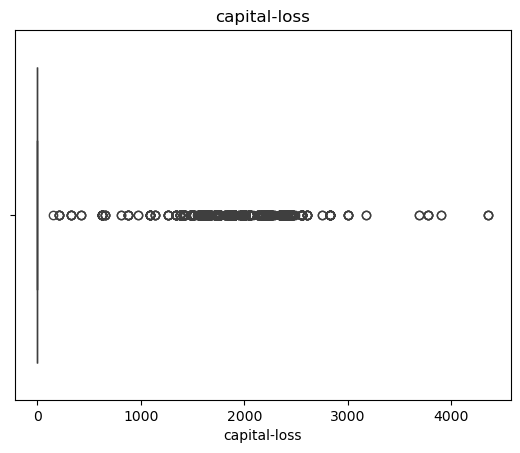

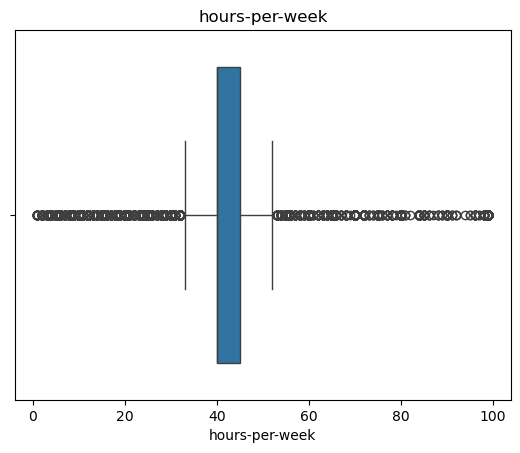

In [40]:
# DETECTTING OUTLIERS
numerical_cols = df.select_dtypes(include=['int64']).columns

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [41]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(28560, 15)


In [42]:
X = df.drop("income", axis=1)
y = df["income"]

In [43]:
# identitfying numerical nad categorical\
numerical_features = X.select_dtypes(include=['int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_features)
print("Categorical Columns:", categorical_features)

Numerical Columns: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical Columns: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')


In [44]:
# Numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [45]:
# categorical pipleine
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [46]:
# Column Transformer
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [75]:
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [76]:
X = df.drop("income", axis=1)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [47]:
# Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])


In [50]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

In [51]:
# Training prediction
train_pred = pipeline_lr.predict(X_train)

In [52]:
# Testing Prediction
test_pred = pipeline_lr.predict(X_test)

In [53]:
print("Logistic Regression")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Logistic Regression
Training Accuracy: 0.8423494397759104
Testing Accuracy: 0.8405112044817927


In [54]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4486
        >50K       0.67      0.50      0.57      1226

    accuracy                           0.84      5712
   macro avg       0.77      0.72      0.74      5712
weighted avg       0.83      0.84      0.83      5712



# DECISION TREE


In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
pipeline_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier())
])


In [28]:
pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier())])

In [29]:
train_pred = pipeline_dt.predict(X_train)
test_pred = pipeline_dt.predict(X_test)

In [30]:
print("Decision Tree")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Decision Tree
Training Accuracy: 0.9998686974789915
Testing Accuracy: 0.7778361344537815


In [31]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.86      0.85      0.86      4486
        >50K       0.48      0.51      0.50      1226

    accuracy                           0.78      5712
   macro avg       0.67      0.68      0.68      5712
weighted avg       0.78      0.78      0.78      5712



# KNN

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
pipeline_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])


In [34]:
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', KNeighborsClassifier())])

In [35]:
train_pred = pipeline_knn.predict(X_train)
test_pred = pipeline_knn.predict(X_test)

In [36]:
print("KNN")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

KNN
Training Accuracy: 0.8738182773109243
Testing Accuracy: 0.8273809523809523


In [37]:

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      4486
        >50K       0.61      0.54      0.57      1226

    accuracy                           0.83      5712
   macro avg       0.74      0.72      0.73      5712
weighted avg       0.82      0.83      0.82      5712



# NAIVE BAYES

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

In [39]:
pipeline_nb = Pipeline([
    ("preprocessor", preprocessor),
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("classifier", GaussianNB())
])

In [40]:
pipeline_nb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('to_dense',
                 FunctionTransformer(accept_sparse=True,
                                     func=<function <lambda> at 0x000001E4A3B1C680>)),
                ('classifier', GaussianNB())])

In [41]:
train_pred = pipeline_nb.predict(X_train)
test_pred = pipeline_nb.predict(X_test)


In [42]:
print("Naive Bayes")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Naive Bayes
Training Accuracy: 0.5308560924369747
Testing Accuracy: 0.5250350140056023


In [43]:

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.96      0.41      0.58      4486
        >50K       0.30      0.94      0.46      1226

    accuracy                           0.53      5712
   macro avg       0.63      0.68      0.52      5712
weighted avg       0.82      0.53      0.55      5712



# RANDOM FOREST

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100))
])

In [46]:
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier())])

In [47]:
train_pred = pipeline_rf.predict(X_train)
test_pred = pipeline_rf.predict(X_test)

In [48]:
print("Random Forest")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Random Forest
Training Accuracy: 0.9998686974789915
Testing Accuracy: 0.8245798319327731


In [49]:
print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      4486
        >50K       0.61      0.50      0.55      1226

    accuracy                           0.82      5712
   macro avg       0.74      0.71      0.72      5712
weighted avg       0.81      0.82      0.82      5712



# SVM

In [50]:
from sklearn.svm import SVC

In [51]:

pipeline_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

In [52]:
pipeline_svm.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', SVC())])

In [53]:

train_pred = pipeline_svm.predict(X_train)
test_pred = pipeline_svm.predict(X_test)

In [54]:

print("SVM")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

SVM
Training Accuracy: 0.8493960084033614
Testing Accuracy: 0.8373599439775911


# ADA BOOSTING

In [55]:
from sklearn.ensemble import AdaBoostClassifier

In [56]:
pipeline_ada = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(n_estimators=100))
])

In [57]:
pipeline_ada.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', AdaBoostClassifier(n_estimators=100))])

In [58]:
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))


Training Accuracy: 0.8493960084033614
Testing Accuracy: 0.8373599439775911


In [59]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

       <=50K       0.86      0.94      0.90      4486
        >50K       0.68      0.46      0.55      1226

    accuracy                           0.84      5712
   macro avg       0.77      0.70      0.72      5712
weighted avg       0.82      0.84      0.83      5712



# GRADIENT BOOSTING

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

In [61]:
pipeline_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier())
])

In [62]:
pipeline_gb.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', GradientBoostingClassifier())])

In [63]:
train_pred = pipeline_gb.predict(X_train)
test_pred = pipeline_gb.predict(X_test)


In [64]:
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Training Accuracy: 0.8492209383753502
Testing Accuracy: 0.8392857142857143


In [65]:
print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4486
        >50K       0.67      0.49      0.57      1226

    accuracy                           0.84      5712
   macro avg       0.77      0.71      0.73      5712
weighted avg       0.83      0.84      0.83      5712



# XG BOOSTING

In [1]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, name):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)
    print("Training Accuracy:", accuracy_score(y_train, train_pred))
    print("Testing Accuracy:", accuracy_score(y_test, test_pred))
    print("\nClassification Report")
    print(classification_report(y_test, test_pred))

In [81]:
from xgboost import XGBClassifier

evaluate_model(
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss"
    ),
    "XGBoost"
)

Training Accuracy: 0.8613007703081232
Testing Accuracy: 0.84156162464986

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4486
           1       0.67      0.51      0.58      1226

    accuracy                           0.84      5712
   macro avg       0.77      0.72      0.74      5712
weighted avg       0.83      0.84      0.83      5712

